# Convolutional Neural Networks (CNNs)

**Author:** *Corneliu Catlabuga*

**Group:** *IS-251M*

## Imports

In [ ]:
from keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalMaxPool2D, GlobalAveragePooling2D, Lambda
from keras.applications import ResNet50, InceptionV3
from keras.applications.resnet import preprocess_input
from keras.utils import image_dataset_from_directory
from keras import Sequential
from matplotlib import pyplot as plt
import kagglehub as kh

## Parameters

In [51]:
DATASET = "olafkrastovski/handwritten-digits-0-9"
DOWNLOAD_PATH = f"data/{DATASET}"
INPUT_SHAPE = (224, 224, 3)
EPOCHS = 10
BATCH_SIZE = 32

## Dataset Aquisition

In [52]:
df_path = kh.dataset_download(DATASET, output_dir=DOWNLOAD_PATH)

## Dataset Splitting

In [53]:
train_ds = image_dataset_from_directory(
    df_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    df_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=BATCH_SIZE
)

Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.


## Model Definition and Compilation

In [54]:
model = Sequential()

model.add(Conv2D(input_shape=INPUT_SHAPE, padding='same', filters=32, kernel_size=(7, 7)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, padding='valid', kernel_size=(5, 5)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Conv2D(filters=256, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(filters=256, kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(GlobalMaxPool2D())

model.add(Dense(units=256))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(units=10))
model.add(Activation('softmax'))

/home/muffindud/Documents/RNIP/lab2/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_663 (Conv2D)             │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_665 (Activation)     │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_663         │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_664 (Conv2D)             │ (None, 108, 108, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_666 (Activation)     │ (None, 108, 108, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_664         │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_665 (Conv2D)             │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_667 (Activation)     │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_665         │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_666 (Conv2D)             │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_668 (Activation)     │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_666         │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_667 (Conv2D)             │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_669 (Activation)     │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_667         │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,086,410 (4.14 MB)

 Trainable params: 1,084,938 (4.14 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [56]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1778061006.459239   21989 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314142__.84


538/539 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4825 - loss: 2.1757

I0000 00:00:1778061046.065684   21989 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314142__.84


539/539 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.7064 - loss: 1.0192 - val_accuracy: 0.7808 - val_loss: 0.7540
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 30s 56ms/step - accuracy: 0.9261 - loss: 0.2337 - val_accuracy: 0.5122 - val_loss: 1.2592
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.9502 - loss: 0.1561 - val_accuracy: 0.6064 - val_loss: 1.0004
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.9565 - loss: 0.1371 - val_accuracy: 0.6894 - val_loss: 0.8952
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9622 - loss: 0.1170 - val_accuracy: 0.1884 - val_loss: 5.6997
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.9692 - loss: 0.1015 - val_accuracy: 0.3250 - val_loss: 2.7566
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.9685 - loss: 0.0988 - val_accuracy: 0.3343 - val_loss: 2.5067
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.9744 - loss: 0.0831 - val_accurac

Evaluating model...
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6240 - loss: 1.6599
Validation Loss: 1.6599
Validation Accuracy: 0.6240


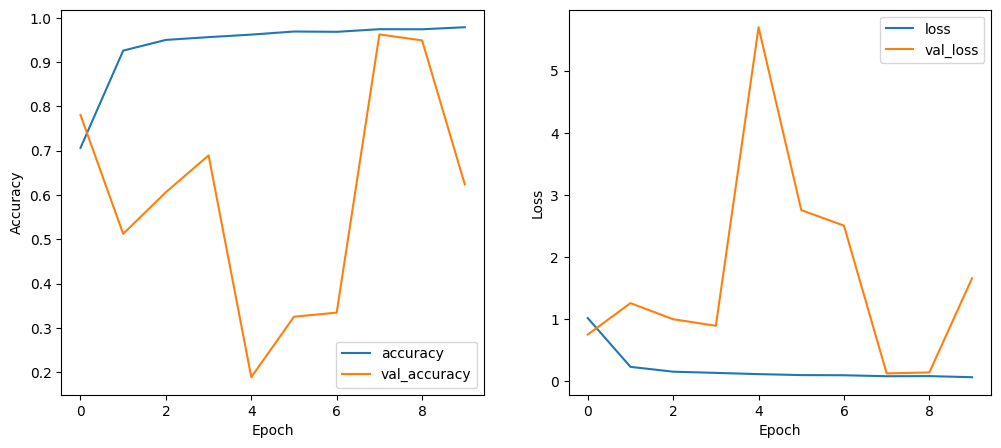

In [71]:
print("Evaluating model...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

In [59]:
model.save('models/handwritten_digits_model.keras')

## ResNet50

In [60]:
base_resnet_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

base_resnet_model.trainable = False

resnet_model = Sequential([
    base_resnet_model,
    GlobalMaxPool2D(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

resnet_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_3          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [61]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1778061333.572767   21992 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_353487__.182


537/539 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7195 - loss: 1.5705

I0000 00:00:1778061356.896624   21993 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_353487__.182


539/539 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.8479 - loss: 0.6137 - val_accuracy: 0.9469 - val_loss: 0.1632
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.9402 - loss: 0.1754 - val_accuracy: 0.9703 - val_loss: 0.0994
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.9581 - loss: 0.1289 - val_accuracy: 0.9752 - val_loss: 0.0792
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9588 - loss: 0.1227 - val_accuracy: 0.9666 - val_loss: 0.1092
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9697 - loss: 0.0908 - val_accuracy: 0.9701 - val_loss: 0.0945
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9677 - loss: 0.0980 - val_accuracy: 0.9766 - val_loss: 0.0701
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9732 - loss: 0.0830 - val_accuracy: 0.9705 - val_loss: 0.0998
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9731 - loss: 0.0825 - val_accurac

Evaluating ResNet model...
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9763 - loss: 0.0765
Validation Loss: 0.0765
Validation Accuracy: 0.9763


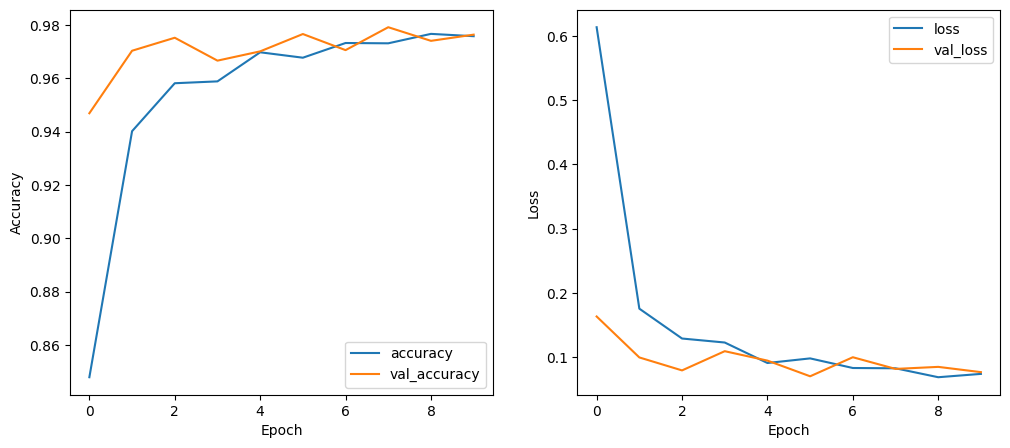

In [78]:
print("Evaluating ResNet model...")

loss, accuracy = resnet_model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['accuracy'], label='accuracy')
plt.plot(resnet_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['loss'], label='loss')
plt.plot(resnet_history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

In [64]:
# Save the model
resnet_model.save('models/handwritten_digits_model_resnet.keras')

## InceptionV3

In [65]:
base_inception_model = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)

base_inception_model.trainable = False

inception_model = Sequential([
    Lambda(preprocess_input, input_shape=INPUT_SHAPE),
    base_inception_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

inception_model.summary()

/home/muffindud/Documents/RNIP/lab2/venv/lib/python3.12/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_4 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,898 (85.18 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [66]:
inception_model.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [67]:
inception_history = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


I0000 00:00:1778061615.344613   21991 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_397530__.213


538/539 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1838 - loss: 7.8782

I0000 00:00:1778061634.523522   21993 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_397530__.213


539/539 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.2330 - loss: 3.4012 - val_accuracy: 0.3575 - val_loss: 1.8135
Epoch 2/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.3123 - loss: 1.8646 - val_accuracy: 0.3693 - val_loss: 1.7737
Epoch 3/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.3629 - loss: 1.7342 - val_accuracy: 0.4839 - val_loss: 1.4396
Epoch 4/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4134 - loss: 1.6206 - val_accuracy: 0.5486 - val_loss: 1.4364
Epoch 5/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4449 - loss: 1.5471 - val_accuracy: 0.5885 - val_loss: 1.2646
Epoch 6/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4672 - loss: 1.5008 - val_accuracy: 0.5973 - val_loss: 1.3030
Epoch 7/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4806 - loss: 1.4601 - val_accuracy: 0.5973 - val_loss: 1.1916
Epoch 8/10
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4972 - loss: 1.4312 - val_accurac

Evaluating InceptionV3 model...
135/135 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6806 - loss: 1.0922
Validation Loss: 1.0922
Validation Accuracy: 0.6806


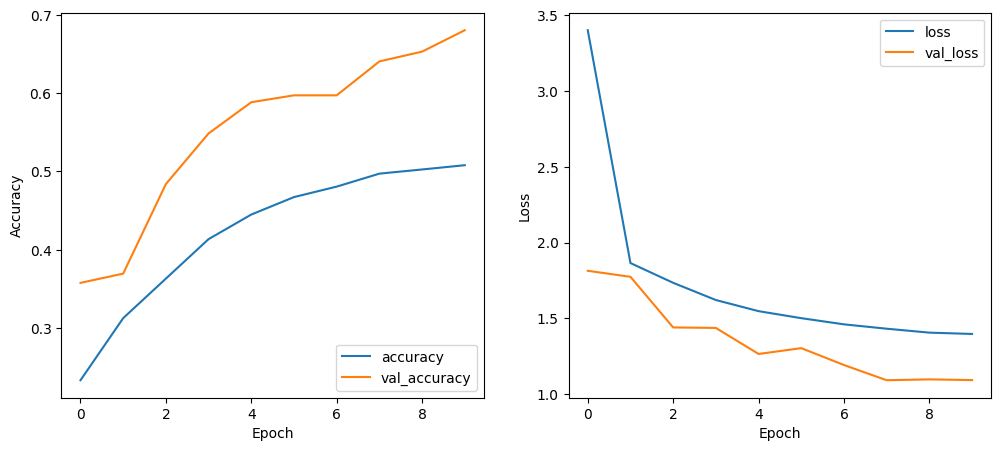

In [77]:
print("Evaluating InceptionV3 model...")

loss, accuracy = inception_model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(inception_history.history['accuracy'], label='accuracy')
plt.plot(inception_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(inception_history.history['loss'], label='loss')
plt.plot(inception_history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

In [69]:
inception_model.save('models/handwritten_digits_model_inception.keras')